In [1]:
from IPython.core.pylabtools import figsize
%matplotlib inline
from statistics import correlation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lead_scoring.src.data_loader import charger_donnees, apercu


In [2]:
df= charger_donnees()
apercu(df)

Dimensions : 11162 lignes x 17 colonnes

Valeurs manquantes :
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Distribution cible :
deposit
0    5873
1    5289
Name: count, dtype: int64

Taux de souscription : 47.38%


In [3]:

df.describe()

,age,balance,day,duration,campaign,pdays,previous,deposit
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557,0.473840
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007,0.499338
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000,1.000000


## Analyse — Statistiques descriptives

- **`balance`** : forte dispersion (std = 3225, min = -6847€) → présence d'outliers, à traiter en preprocessing
- **`duration`** : très étalée → variable potentiellement prédictive mais biaisée (inconnue avant l'appel)
- **`pdays`** : min à -1 → valeur codée "jamais contacté", pas une vraie valeur numérique → à traiter en S2
- **`campaign`** : max à 63 contacts → valeur aberrante
- **`deposit`** : moyenne à 0.47 → dataset quasi-équilibré, pas besoin de rééchantillonnage


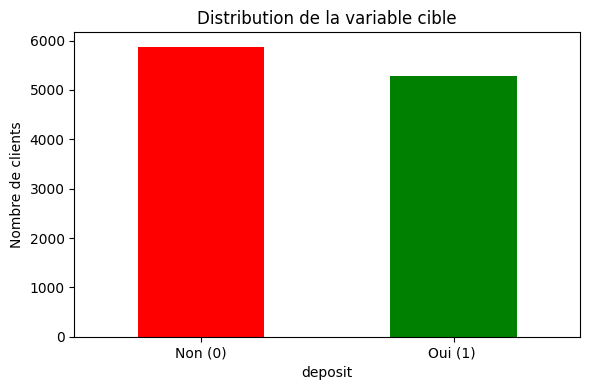

In [4]:
fig, ax = plt.subplots(figsize=(6,4))
df["deposit"].value_counts().plot(kind="bar", ax=ax, color=["red", "green"])

ax.set_xticklabels(["Non (0)", "Oui (1) "], rotation=0)
ax.set_title("Distribution de la variable cible")
ax.set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()


## Analyse — Distribution de la variable cible

- Les deux classes sont quasi-équilibrées : **5 873 "non" (53%)** vs **5 289 "oui" (47%)**
- L'écart est faible (~6%) → pas besoin de techniques de rééchantillonnage
- Le modèle aura suffisamment d'exemples des deux classes pour apprendre correctement

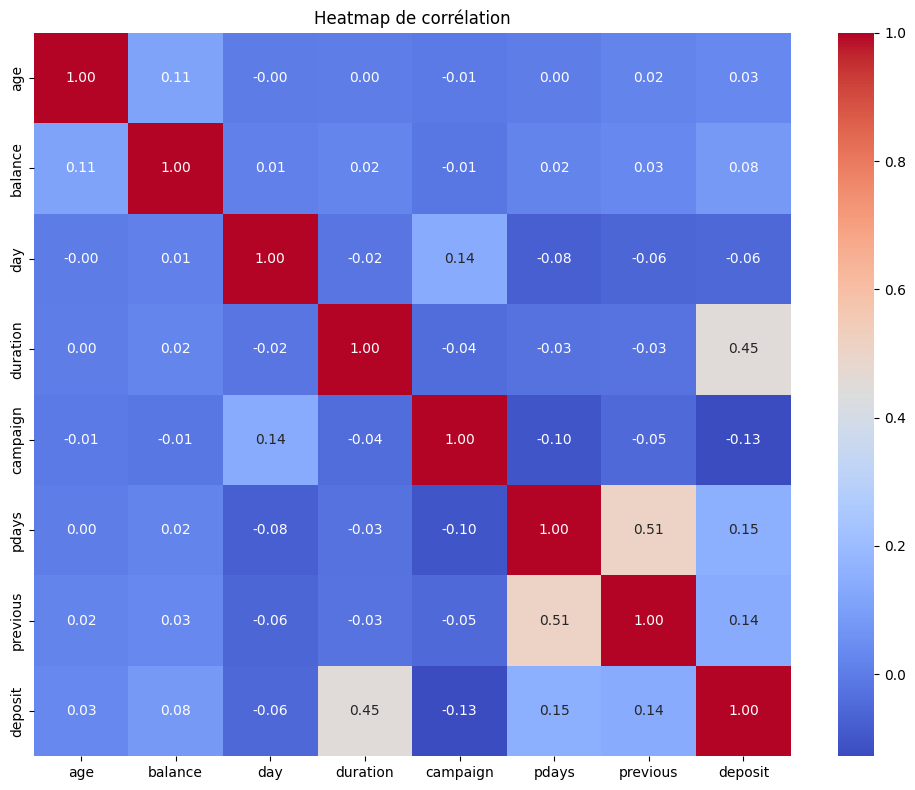

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation, annot=True, fmt=".2f", cmap = "coolwarm", ax = ax)

ax.set_title("Heatmap de corrélation")
plt.tight_layout()
plt.show()

## Analyse — Heatmap de corrélation

**Corrélations avec `deposit` (la cible) :**
- `duration` = 0.45 → corrélation positive la plus forte : plus l'appel est long, plus le client souscrit
- `campaign` = -0.13 → corrélation négative : trop de contacts nuit à la souscription
- `previous` = 0.14, `pdays` = 0.15 → légère corrélation positive avec l'historique campagnes
- `age`, `balance`, `day` ≈ 0 → pas de relation linéaire directe avec la cible

**Corrélations entre variables :**
- `previous` ↔ `pdays` = 0.51 → quasi-redondantes, portent une information similaire

**Conclusion :**
- Aucune variable n'est dominante (max 0.45) → le modèle devra combiner plusieurs variables
- Une corrélation faible ≠ variable inutile : Random Forest peut détecter des patterns non-linéaires
- `duration` est la variable la plus prédictive mais problématique (inconnue avant l'appel)


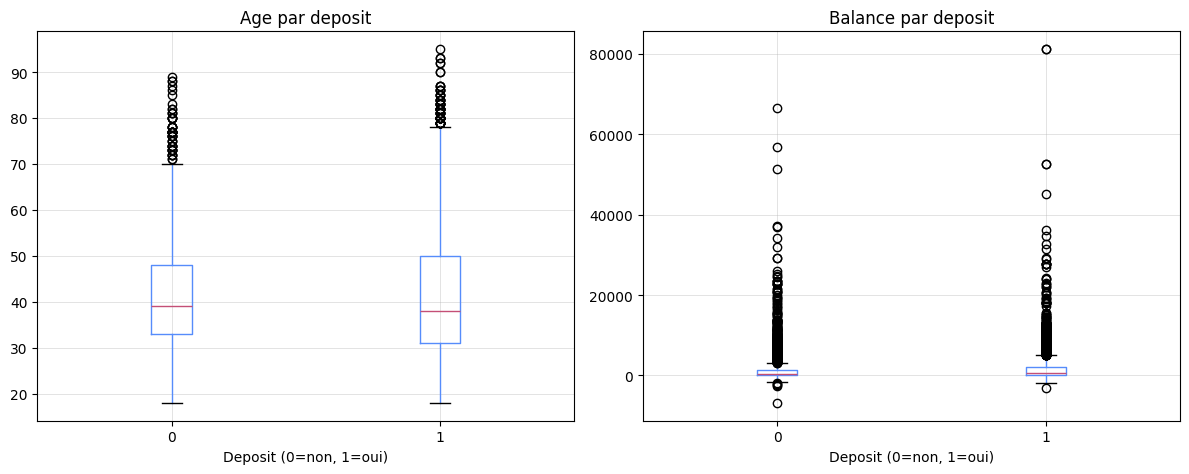

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column="age", by="deposit", ax=axes[0])
axes[0].set_title("Age par deposit")
axes[0].set_xlabel("Deposit (0=non, 1=oui)")

df.boxplot(column="balance", by="deposit", ax=axes[1])
axes[1].set_title("Balance par deposit")
axes[1].set_xlabel("Deposit (0=non, 1=oui)")

plt.suptitle("")
plt.tight_layout()
plt.show()


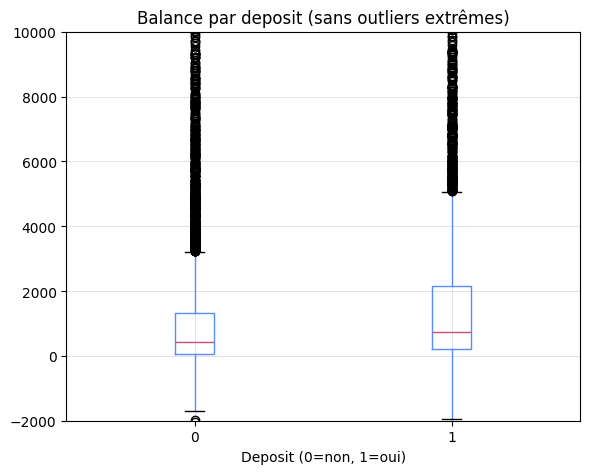

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
df.boxplot(column="balance", by="deposit", ax=ax)
ax.set_ylim(-2000, 10000)
ax.set_title("Balance par deposit (sans outliers extrêmes)")
ax.set_xlabel("Deposit (0=non, 1=oui)")
plt.suptitle("")
plt.tight_layout()
plt.show()

## Analyse — Boxplots

**`Age` :**
- Les deux groupes ont une distribution similaire (médiane ~40 ans)
- L'âge seul ne distingue pas bien les souscripteurs des non-souscripteurs

**`Balance` :**
- Les clients qui souscrivent (deposit=1) ont un solde médian légèrement plus élevé (~800€ vs ~600€)
- La boîte de deposit=1 est plus large → plus de variabilité dans ce groupe
- Présence de nombreux outliers dans les deux groupes → à traiter en preprocessing (S2)
- `balance` contribue à la prédiction mais n'est pas suffisante seule


## Résumé S1

Le dataset est **propre et équilibré**, pas de valeurs manquantes, presque autant de "oui" que de "non".
On peut passer au preprocessing sans nettoyage majeur.

**Variables les plus intéressantes pour la prédiction :**
- `duration` : corrélation 0.45 avec deposit (mais inconnue avant l'appel)
- `balance` : les souscripteurs ont un solde légèrement plus élevé
- `previous`, `pdays` :l'historique de campagnes a un léger impact positif

**3 choses à régler en S2 :**
1. `balance` a des outliers extrêmes à plafonner
2. `pdays = -1` est une valeur codée à transformer
3. Les colonnes texte (`job`, `marital`, `education`…) doivent être encodées en chiffres
